In [ ]:
import pandas as pd
import numpy as np

from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

import time

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# 1. Load the cleaned Phase 1 dataset from the Parquet file
df = pd.read_parquet("../data/processed/clustering_input_clean.parquet")

# 2. Display the overall dataset dimensions (number of rows and columns)
print(f"Total rows and columns: {df.shape}")

# 3. Display the names of all columns
print("\nAll columns in the dataset:")
print(df.columns.tolist())

# 4. Display the first five rows
df.head()

Total rows and columns: (999998, 19)

All columns in the dataset:
['ad_id', 'city_slug', 'deal_type_cat', 'utm_zone', 'property_category_cat', 'price_position_z_raw', 'is_sale_raw', 'building_size_raw', 'rooms_count_raw', 'utm_easting_raw', 'utm_northing_raw', 'amenity_score_raw', 'price_position_z_scaled', 'is_sale_scaled', 'building_size_scaled', 'rooms_count_scaled', 'utm_easting_scaled', 'utm_northing_scaled', 'amenity_score_scaled']


,ad_id,city_slug,deal_type_cat,utm_zone,property_category_cat,price_position_z_raw,is_sale_raw,building_size_raw,rooms_count_raw,utm_easting_raw,utm_northing_raw,amenity_score_raw,price_position_z_scaled,is_sale_scaled,building_size_scaled,rooms_count_scaled,utm_easting_scaled,utm_northing_scaled,amenity_score_scaled
0,0,karaj,temporary_rent,39,villa,0.256750,0.0,292.5,3.0,4.942723e+05,3.963064e+06,0.0,0.288886,-1.218564,2.070845,1.452489,-0.250704,0.388086,-1.131432
1,1,tehran,sell,39,apartment,0.845426,1.0,60.0,1.0,5.399990e+05,3.958893e+06,1.0,0.960003,0.820638,-0.884402,-1.023646,-0.105017,0.373613,1.234447
2,2,tehran,rent,39,apartment,1.009912,0.0,132.0,3.0,5.337844e+05,3.951168e+06,1.0,1.147523,-1.218564,0.030771,1.452489,-0.124817,0.346808,1.234447
3,3,tehran,rent,39,office,1.840001,0.0,90.0,1.0,5.385443e+05,3.960860e+06,1.0,2.093860,-1.218564,-0.503080,-1.023646,-0.109652,0.380438,1.234447
4,4,mashhad,sell,39,apartment,0.529831,1.0,115.0,2.0,1.273229e+06,4.048566e+06,1.0,0.600210,0.820638,-0.185312,0.214421,2.231074,0.684778,1.234447


In [ ]:
# 1. Define the exact seven standardized features for clustering
cluster_features = [
    "price_position_z_scaled",
    "is_sale_scaled",
    "building_size_scaled",
    "rooms_count_scaled",
    "utm_easting_scaled",
    "utm_northing_scaled",
    "amenity_score_scaled",
]

# 2. Create the input feature matrix for the model
X = df[cluster_features]

# 3. Check for missing values (NaN) in each feature
missing_counts = X.isnull().sum()
print("Missing values in features:")
print(missing_counts)

# 4. Display summary statistics (standardized features should have a mean near 0 and a standard deviation near 1)
print("\nDescriptive statistics:")
X.describe().round(3)

Missing values in features:
price_position_z_scaled    0
is_sale_scaled             0
building_size_scaled       0
rooms_count_scaled         0
utm_easting_scaled         0
utm_northing_scaled        0
amenity_score_scaled       0
dtype: int64

Descriptive statistics:


,price_position_z_scaled,is_sale_scaled,building_size_scaled,rooms_count_scaled,utm_easting_scaled,utm_northing_scaled,amenity_score_scaled
count,999998.000,999998.000,999998.000,999998.000,999998.000,999998.000,999998.000
mean,0.000,0.000,-0.000,0.000,-0.000,-0.000,0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-2.551,-1.219,-1.634,-2.262,-2.352,-3.701,-1.131
25%,-0.637,-1.219,-0.694,-1.024,-0.466,-0.340,-1.131
50%,-0.041,0.821,-0.338,0.214,-0.130,0.352,0.052
75%,0.639,0.821,0.412,0.214,0.128,0.674,1.234
max,2.554,0.821,2.071,2.072,3.533,1.933,1.234


In [ ]:
# 1. Perform random sampling for computationally expensive evaluation metrics (Silhouette & DBI)
SAMPLE_SIZE = 10000
X_eval_sample = X.sample(n=SAMPLE_SIZE, random_state=42)

# 2. Initialize lists to store evaluation metrics
k_values = list(range(1, 21))
inertias = []
silhouette_scores = []
db_scores = []

print("Running K-Means evaluation for k=1 to 20...\n")
start_time = time.time()

for k in k_values:
    step_start = time.time()

    # Initialize and fit the model using k-means++ initialization and a fixed seed
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    kmeans.fit(X)

    # 1. Record inertia (calculated on the full dataset)
    inertias.append(kmeans.inertia_)

    # 2 & 3. Compute Silhouette and Davies-Bouldin only for k >= 2
    if k >= 2:
        sample_preds = kmeans.predict(X_eval_sample)
        sil = silhouette_score(X_eval_sample, sample_preds)
        db = davies_bouldin_score(X_eval_sample, sample_preds)

        silhouette_scores.append(sil)
        db_scores.append(db)
        print(
            f"k={k:2d} | Inertia: {kmeans.inertia_:12.2f} | Silhouette: {sil:.4f} | DBI: {db:.4f} | Time: {time.time() - step_start:.1f}s"
        )
    else:
        print(
            f"k={k:2d} | Inertia: {kmeans.inertia_:12.2f} | (Metrics undefined for k=1) | Time: {time.time() - step_start:.1f}s"
        )

total_time = time.time() - start_time
print(f"\nDone in {total_time/60:.2f} minutes.")

Running K-Means evaluation for k=1 to 20...

k= 1 | Inertia:   6999986.00 | (Metrics undefined for k=1) | Time: 5.9s
k= 2 | Inertia:   5823658.36 | Silhouette: 0.1655 | DBI: 2.1241 | Time: 9.9s
k= 3 | Inertia:   4985288.68 | Silhouette: 0.1988 | DBI: 1.7212 | Time: 9.8s
k= 4 | Inertia:   4469170.92 | Silhouette: 0.2049 | DBI: 1.5412 | Time: 11.2s
k= 5 | Inertia:   4035077.30 | Silhouette: 0.1994 | DBI: 1.4877 | Time: 12.4s
k= 6 | Inertia:   3729973.90 | Silhouette: 0.2005 | DBI: 1.4444 | Time: 14.1s
k= 7 | Inertia:   3417844.95 | Silhouette: 0.2117 | DBI: 1.3577 | Time: 16.1s
k= 8 | Inertia:   3223856.74 | Silhouette: 0.2074 | DBI: 1.4006 | Time: 17.8s
k= 9 | Inertia:   3081792.55 | Silhouette: 0.2043 | DBI: 1.4682 | Time: 21.5s
k=10 | Inertia:   2950660.73 | Silhouette: 0.2106 | DBI: 1.4671 | Time: 21.5s
k=11 | Inertia:   2844836.77 | Silhouette: 0.2097 | DBI: 1.5344 | Time: 21.2s
k=12 | Inertia:   2708530.78 | Silhouette: 0.2199 | DBI: 1.4529 | Time: 26.2s
k=13 | Inertia:   2618784.3

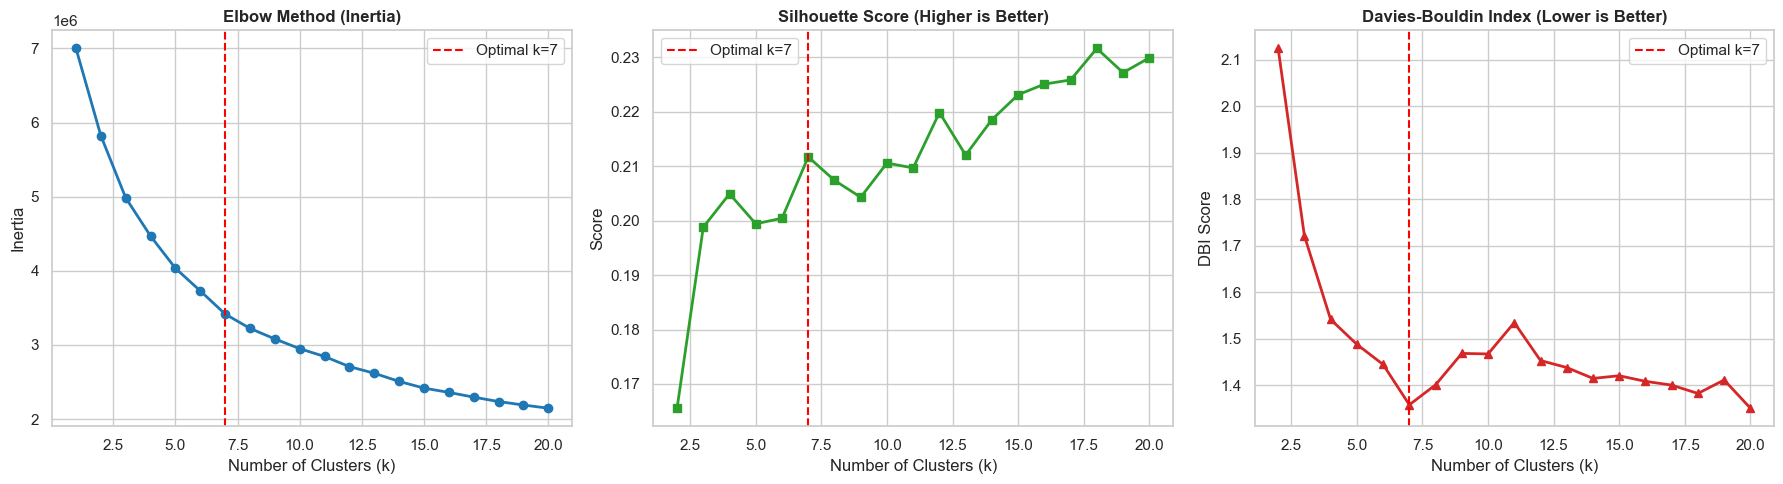

In [ ]:
# Set up the visualization style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Plot the Elbow Method (Inertia)
axes[0].plot(k_values, inertias, marker="o", color="#1f77b4", linewidth=2)
axes[0].axvline(x=7, color="red", linestyle="--", label="Optimal k=7")
axes[0].set_title("Elbow Method (Inertia)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].legend()

# 2. Plot the Silhouette Score
axes[1].plot(k_values[1:], silhouette_scores, marker="s", color="#2ca02c", linewidth=2)
axes[1].axvline(x=7, color="red", linestyle="--", label="Optimal k=7")
axes[1].set_title("Silhouette Score (Higher is Better)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Score")
axes[1].legend()

# 3. Plot the Davies-Bouldin Index
axes[2].plot(k_values[1:], db_scores, marker="^", color="#d62728", linewidth=2)
axes[2].axvline(x=7, color="red", linestyle="--", label="Optimal k=7")
axes[2].set_title(
    "Davies-Bouldin Index (Lower is Better)", fontsize=12, fontweight="bold"
)
axes[2].set_xlabel("Number of Clusters (k)")
axes[2].set_ylabel("DBI Score")
axes[2].legend()

# Optimize layout and display the plots
plt.tight_layout()
plt.show()

## Cluster Evaluation & Analysis

### 1. Metric Observations & Trade-offs
- **WCSS / Inertia (Elbow Method):**
  - Exhibits a smooth, continuous monotonic decline without an abrupt or sharp "elbow" point, which is typical for large, continuous real estate datasets.
  - Diminishing returns in inertia reduction begin to set in noticeably around the range of $k = 5$ to $k = 7$.
  - *Limitation:* Inertia is unnormalized and naturally prefers higher $k$, meaning it cannot be used in isolation to pick an optimal cluster count.

- **Silhouette Score:**
  - Shows a distinct **local maximum** at $k = 7$ (0.2117) compared to its immediate neighbors ($k=6$: 0.2005, $k=8$: 0.2074).
  - Higher scores appear at much larger cluster counts ($k = 18$ reaches 0.2317).
  - *Limitation:* Computed on an evaluation sample ($N=10,000$) due to $O(N^2)$ quadratic complexity on 1M rows; hence, scores represent statistical estimates rather than exact full-dataset metrics.

- **Davies–Bouldin Index (DBI):**
  - Shows a prominent **local minimum** (best separation/compactness) at $k = 7$ (1.3577), outperforming neighboring cluster counts.
  - A slightly lower score occurs at $k = 20$ (1.3504).
  - *Limitation:* Sensitive to cluster centroid geometry and penalizes complex non-spherical sub-distributions.

---

### 2. Final Choice: $k = 7$
While larger values of $k$ (e.g., $k=18$ or $k=20$) yield slightly better geometric validation scores, they carry a high risk of **over-segmentation**, creating thin, redundant clusters that hinder operational interpretability.

**$k = 7$** is selected as the optimal parsimonious trade-off because:
1. It coincides with the diminishing-returns transition on the inertia curve.
2. It simultaneously captures a strong local peak in Silhouette and a local valley in DBI.
3. A 7-cluster schema is well-suited for practical real-estate market segmentation (e.g., distinguishing luxury metropolitan units, budget/suburban flats, villas, and commercial/raw categories).


In [ ]:
# Set the path for the output reports directory (relative to the notebook location)
reports_dir = Path("../outputs/reports")
# Create the directory if it does not already exist
reports_dir.mkdir(parents=True, exist_ok=True)

# Compile the evaluation metrics into a pandas DataFrame
metrics_df = pd.DataFrame(
    {
        "k": k_values,
        "inertia": inertias,
        # Silhouette and Davies-Bouldin scores are undefined for k=1, so we insert None
        "silhouette": [None] + silhouette_scores,
        "davies_bouldin": [None] + db_scores,
    }
)

# Define the output file path and save the metrics to a CSV file
output_path = reports_dir / "kmeans_evaluation_metrics.csv"
metrics_df.to_csv(output_path, index=False)

# Print confirmation of the saved file
print(f"Metrics successfully saved to: {output_path}")

Metrics successfully saved to: ..\outputs\reports\kmeans_evaluation_metrics.csv
